# EDA

## 1. Library Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data.loader import load_dataset
from analysis.profiler import DataProfiler
from visualization.plots import plot_missing_distribution, plot_target_distribution

## 2. Data Load

In [2]:
df = load_dataset("uci-secom.csv")
df.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


## 3. Missing Value Analysis

In [3]:
profiler = DataProfiler(df)
missing_columns = profiler.missing_columns()
missing_columns

,missing count per columns,missing ratio per columns (%)
158,1429,91.19
292,1429,91.19
293,1429,91.19
157,1429,91.19
85,1341,85.58
...,...,...
386,0,0.00
361,0,0.00
360,0,0.00
359,0,0.00


In [4]:
missing_columns.describe()

,missing count per columns,missing ratio per columns (%)
count,592.000000,592.000000
mean,70.863176,4.520929
std,241.476304,15.409879
min,0.000000,0.000000
25%,2.000000,0.130000
50%,6.000000,0.380000
75%,9.000000,0.570000
max,1429.000000,91.190000


In [5]:
missing_columns["missing ratio per columns (%)"].value_counts().sort_index()

missing ratio per columns (%)
0.00      54
0.06      92
0.13      84
0.19      24
0.26      24
0.32       3
0.38     100
0.45      20
0.51      12
0.57      48
0.64       4
0.77       4
0.89      20
1.53      43
3.25       8
16.59     12
17.42      8
45.63      4
50.67      4
60.56      4
64.96     12
85.58      4
91.19      4
Name: count, dtype: int64

In [6]:
bins = [-0.1, 0, 1, 5, 10, 20, 40, 60, 80, 100]

labels = [
    "0%",
    "0~1%",
    "1~5%",
    "5~10%",
    "10~20%",
    "20~40%",
    "40~60%",
    "60~80%",
    "80~100%",
]

In [7]:
missing_columns["missing_group"] = pd.cut(
    missing_columns["missing ratio per columns (%)"],
    bins=bins,
    labels=labels,
)

In [8]:
missing_distribution = missing_columns["missing_group"].value_counts().sort_index()
missing_distribution

missing_group
0%          54
0~1%       435
1~5%        51
5~10%        0
10~20%      20
20~40%       0
40~60%       8
60~80%      16
80~100%      8
Name: count, dtype: int64

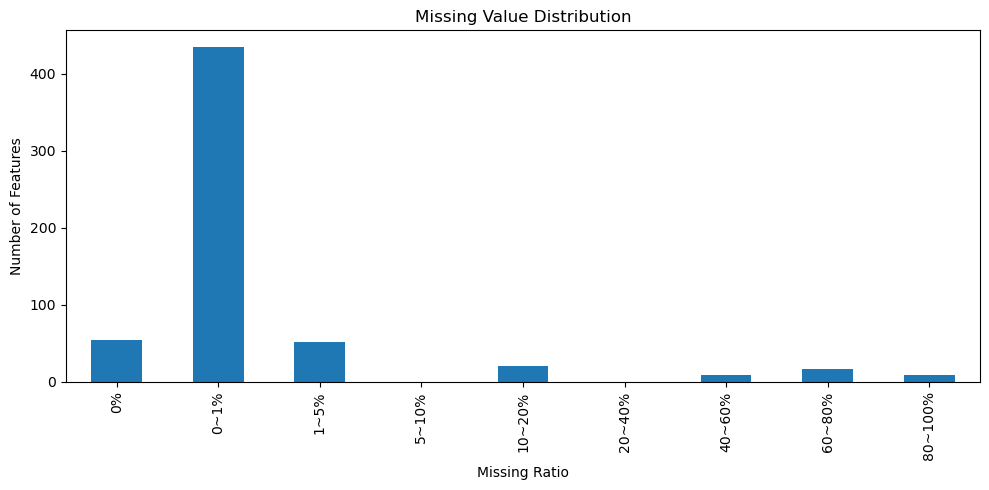

In [11]:
plot_missing_distribution(missing_distribution)

In [9]:
high_missing = missing_columns[
    missing_columns["missing ratio per columns (%)"] >= 80
    ]

high_missing

,missing count per columns,missing ratio per columns (%),missing_group
158,1429,91.19,80~100%
292,1429,91.19,80~100%
293,1429,91.19,80~100%
157,1429,91.19,80~100%
85,1341,85.58,80~100%
492,1341,85.58,80~100%
220,1341,85.58,80~100%
358,1341,85.58,80~100%


In [10]:
len(high_missing)

8

### Interpretation

- 대부분의 컬럼은 결측률이 매우 낮다.
- 일부 컬럼에서만 높은 결측률이 관찰된다.
- 높은 결측률을 가진 피처도 constant feature는 아니었으므로, 단순 제거보다는 정보량과 활용 가능성을 함께 고려할 필요가 있다.
- 따라서 일괄적인 결측치 처리보다는 결측률을 기준으로 처리 전략을 구분하는 것이 적절할 것으로 판단된다.

## 4. Target Analysis

타깃 클래스의 분포를 확인하고 클래스 불균형 정도를 정량적으로 분석한다.

이를 통해 모델 학습 과정에서 필요한 불균형 처리 전략과 성능 평가 지표를 결정한다.

In [11]:
target_summary = profiler.target_summary("Pass/Fail")

pd.Series(target_summary)

dtype                                    int64
non_null_count                            1567
missing count                                0
missing ratio (%)                          0.0
unique                                       2
value_counts                {-1: 1463, 1: 104}
value_counts_ratio (%)    {-1: 93.36, 1: 6.64}
dtype: object

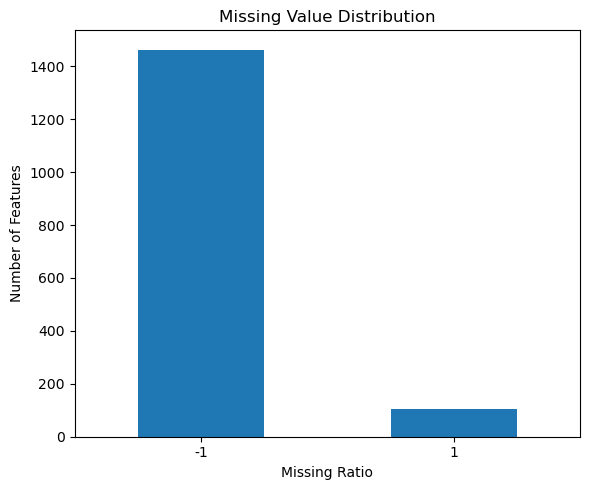

In [12]:
value_counts = (
    pd.Series(target_summary["value_counts"])
    .sort_index()
)

plot_target_distribution(value_counts)

In [13]:
majority = max(target_summary["value_counts"].values())
minority = min(target_summary["value_counts"].values())

imbalance_ratio = round(majority / minority, 2)

imbalance_ratio

14.07

### Interpretation

- 정상(Pass) 클래스가 전체의 대부분을 차지하였다.
- 불량(Fail)은 약 6.6% 수준으로 매우 적은 비율을 차지하였다.
- 클래스 비율은 약 14:1로 불균형한 데이터셋에 해당한다.
- 따라서 Accuracy만으로 모델을 평가할 경우 실제 불량 검출 성능을 제대로 반영하지 못할 가능성이 있다.
- 이후 모델링 단계에서는 Recall, F1-score, PR-AUC 등의 지표를 함께 비교하고, SMOTE와 Class Weight 기반 불균형 처리 방법을 함께 평가할 예정이다.

## 5. Constant Feature Analysis

In [14]:
feature_summary = profiler.features_summary()

constant_features = feature_summary[feature_summary["constant"]]

constant_features

,dtype,non_null_count,missing count per columns,missing ratio per columns (%),constant,unique
5,float64,1553,14,0.89,True,1
13,float64,1564,3,0.19,True,1
42,float64,1566,1,0.06,True,1
49,float64,1566,1,0.06,True,1
52,float64,1566,1,0.06,True,1
...,...,...,...,...,...,...
534,float64,1558,9,0.57,True,1
535,float64,1558,9,0.57,True,1
536,float64,1558,9,0.57,True,1
537,float64,1558,9,0.57,True,1


In [15]:
print(f"고정 변수 개수: {len(constant_features)}")

고정 변수 개수: 116


In [16]:
constant_features.sort_values(by='missing ratio per columns (%)', ascending=False)

,dtype,non_null_count,missing count per columns,missing ratio per columns (%),constant,unique
314,float64,1543,24,1.53,True,1
449,float64,1543,24,1.53,True,1
450,float64,1543,24,1.53,True,1
178,float64,1543,24,1.53,True,1
313,float64,1543,24,1.53,True,1
...,...,...,...,...,...,...
325,float64,1566,1,0.06,True,1
461,float64,1566,1,0.06,True,1
52,float64,1566,1,0.06,True,1
49,float64,1566,1,0.06,True,1


In [17]:
constant_mean = round(constant_features['missing ratio per columns (%)'].mean(), 2)

print(f"고정 변수의 평균 결측률: {constant_mean}%")

고정 변수의 평균 결측률: 0.45%


### Interpretation

- 총 116개의 Constant Feature가 확인되었다.
- 이들 피처의 평균 결측률은 0.45%였으며, 최대 결측률도 1.53%에 불과하였다.
- 따라서 Constant Feature는 높은 결측률로 인해 발생한 것이 아니라, 실제 측정값 자체의 변동이 거의 없는 특성을 가진 것으로 판단된다.
- 이러한 특성은 공정 특성상 값이 일정하게 유지되는 센서일 수도 있고, 측정 시스템의 특성에 의해 발생했을 가능성도 있으나, 제공된 데이터만으로는 원인을 단정할 수 없다.
- 따라서 Feature Selection 단계에서 제거 여부를 성능 실험을 통해 검증할 예정이다.

## 6. Low Variance Feature Analysis

In [18]:
numeric_features = df.drop(columns=["Time", "Pass/Fail"])

variance = numeric_features.var()
variance

0        5420.167484
1        6465.399020
2         871.026144
3      195091.505178
4        3175.946899
           ...      
585        12.802321
586         0.000153
587         0.000078
588         0.000008
589      8815.692532
Length: 590, dtype: float64

In [19]:
variance.describe()

count    5.900000e+02
mean     1.533210e+05
std      1.999010e+06
min      0.000000e+00
25%      9.845754e-06
50%      3.128682e-02
75%      3.973339e+01
max      4.294927e+07
dtype: float64

In [20]:
variance.quantile(
    [
        0,
        0.01,
        0.05,
        0.1,
        0.25,
        0.5,
        0.75,
        0.9,
        0.95,
        0.99,
        1,
    ]
)

0.00    0.000000e+00
0.01    0.000000e+00
0.05    0.000000e+00
0.10    0.000000e+00
0.25    9.845754e-06
0.50    3.128682e-02
0.75    3.973339e+01
0.90    1.549267e+03
0.95    5.890334e+04
0.99    1.069606e+06
1.00    4.294927e+07
dtype: float64

(array([583.,   1.,   1.,   0.,   1.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   1.]),
 array([       0.        ,   858985.41591533,  1717970.83183067,
         2576956.247746  ,  3435941.66366133,  4294927.07957666,
         5153912.495492  ,  6012897.91140733,  6871883.32732266,
         7730868.74323799,  8589854.15915333,  9448839.57506866,
        10307824.99098399, 11166810.40689933, 12025795.82281466,
        12884781.23872999, 13743766.65464532, 14602752.07056066,
        15461737.48647599, 16320722.90239132, 17179708.31830665,
        18038693.73422199, 18897679.15013732, 19756664.56605265,
        20615649.98196799, 21474635.39788332, 22333620.81379865,
        23192606.22971398, 24051591.64562932, 24910577.06154465,
        

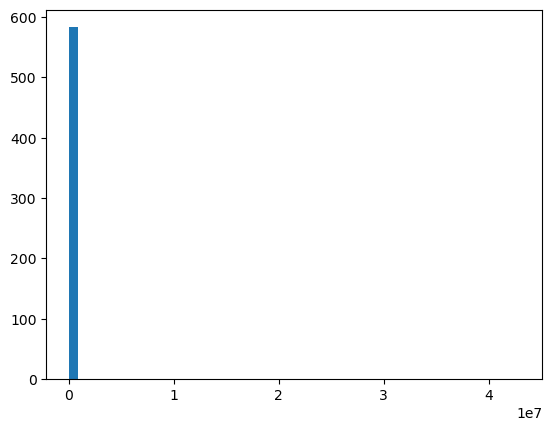

In [21]:
plt.hist(variance, bins=50)

### Observation

- 분산 값의 범위가 매우 넓어 일반 히스토그램에서는 대부분의 Feature가 하나의 구간에 집중된다.

### Decision

- 분산이 0인 Feature는 log10을 계산할 수 없으므로 시각화 대상에서 제외한다.
- 0보다 큰 분산 값에 log10을 적용하여 전체적인 분산 분포를 확인한다.

In [22]:
variance[variance == 0]

5      0.0
13     0.0
42     0.0
49     0.0
52     0.0
      ... 
534    0.0
535    0.0
536    0.0
537    0.0
538    0.0
Length: 116, dtype: float64

In [23]:
variance_nonzero = variance[variance > 0]
variance_nonzero.describe()

count    4.740000e+02
mean     1.908426e+05
std      2.229096e+06
min      1.090102e-08
25%      2.275019e-03
50%      1.384253e+00
75%      1.028604e+02
max      4.294927e+07
dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x204973f5f90>,
 'caps': [<matplotlib.lines.Line2D at 0x204973f71d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x204973f57d0>],
 'medians': [<matplotlib.lines.Line2D at 0x204974083d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x20497408cd0>],
 'means': []}

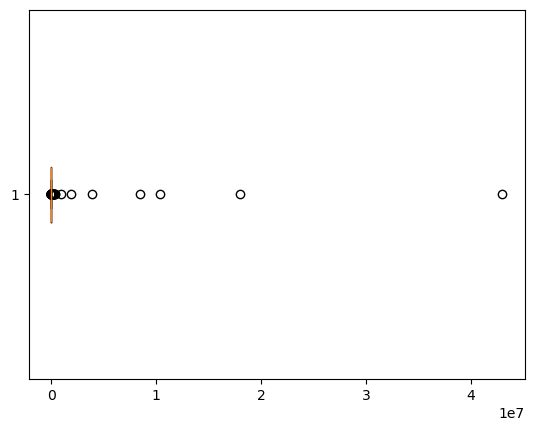

In [24]:
plt.boxplot(
    variance_nonzero,
    vert=False,
)

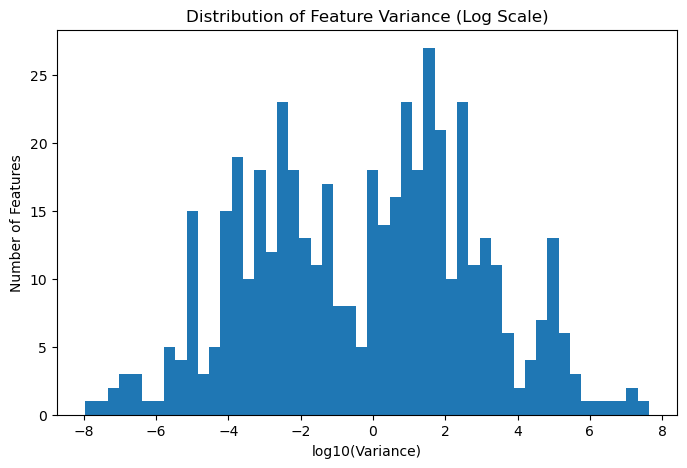

In [25]:
variance_nonzero = variance[variance > 0]

plt.figure(figsize=(8, 5))
plt.hist(np.log10(variance_nonzero), bins=50)
plt.xlabel("log10(Variance)")
plt.ylabel("Number of Features")
plt.title("Distribution of Feature Variance (Log Scale)")
plt.show()

In [26]:
variance_nonzero

0        5420.167484
1        6465.399020
2         871.026144
3      195091.505178
4        3175.946899
           ...      
585        12.802321
586         0.000153
587         0.000078
588         0.000008
589      8815.692532
Length: 474, dtype: float64

In [27]:
np.log10(variance_nonzero)

0      3.734013
1      3.810595
2      2.940031
3      5.290238
4      3.501873
         ...   
585    1.107289
586   -3.816091
587   -4.110291
588   -5.085123
589    3.945256
Length: 474, dtype: float64

In [28]:
np.log10(variance_nonzero)[np.log10(variance_nonzero) < -5]

85    -5.066761
93    -5.042915
94    -7.518229
95    -7.962533
100   -6.898231
101   -7.312150
103   -5.027267
104   -6.140438
106   -5.049264
114   -5.555559
131   -5.295412
143   -5.784353
219   -5.567084
220   -5.402728
238   -5.540151
239   -5.682428
278   -6.936955
288   -5.064460
357   -6.600456
358   -6.807449
365   -5.151541
366   -5.245953
367   -5.137568
368   -5.352802
376   -6.544348
377   -6.662222
392   -5.058722
542   -5.125527
543   -5.628607
544   -7.058826
580   -5.012809
588   -5.085123
dtype: float64

In [29]:
variance_nonzero[np.log10(variance_nonzero)[np.log10(variance_nonzero) < -5].index]

85     8.575094e-06
93     9.059099e-06
94     3.032293e-08
95     1.090102e-08
100    1.264063e-07
101    4.873603e-08
103    9.391460e-06
104    7.237052e-07
106    8.927623e-06
114    2.782538e-06
131    5.065094e-06
143    1.643035e-06
219    2.709667e-06
220    3.956146e-06
238    2.883027e-06
239    2.077649e-06
278    1.156231e-07
288    8.620656e-06
357    2.509253e-07
358    1.557941e-07
365    7.054390e-06
366    5.676064e-06
367    7.285036e-06
368    4.438111e-06
376    2.855300e-07
377    2.176596e-07
392    8.735296e-06
542    7.489852e-06
543    2.351759e-06
544    8.733216e-08
580    9.709368e-06
588    8.220099e-06
dtype: float64

### Interpretation

- Feature의 분산은 매우 넓은 범위에 걸쳐 분포하였다.
- 로그 스케일로 변환한 이후에도 여러 개의 분산 그룹이 존재하는 것으로 보이며, Feature 간 변동성이 크게 다름을 확인하였다.
- 특히 분산이 매우 작은 Feature가 상당수 존재하여, Feature Selection 과정에서 Low Variance Feature 제거 여부를 검토할 필요가 있다.
- 반면 일부 Feature는 매우 큰 분산을 가지므로, 단순히 고정된 Variance Threshold를 적용하기보다 다양한 Threshold를 비교하여 적절한 기준을 결정할 예정이다.

## 7. Variance Threshold

In [30]:
thresholds = [
    0,
    1e-8,
    1e-6,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
    1,
]

results = []

for threshold in thresholds:
    removed = (variance <= threshold).sum()
    remaining = len(variance) - removed

    results.append(
        {
            "threshold": threshold,
            "removed_features": removed,
            "remaining_features": remaining,
        }
    )

variance_threshold_summary = pd.DataFrame(results)

variance_threshold_summary

,threshold,removed_features,remaining_features
0,0.000000e+00,116,474
1,1.000000e-08,116,474
2,1.000000e-06,127,463
3,1.000000e-04,171,419
4,1.000000e-03,221,369
5,1.000000e-02,276,314
6,1.000000e-01,318,272
7,1.000000e+00,345,245


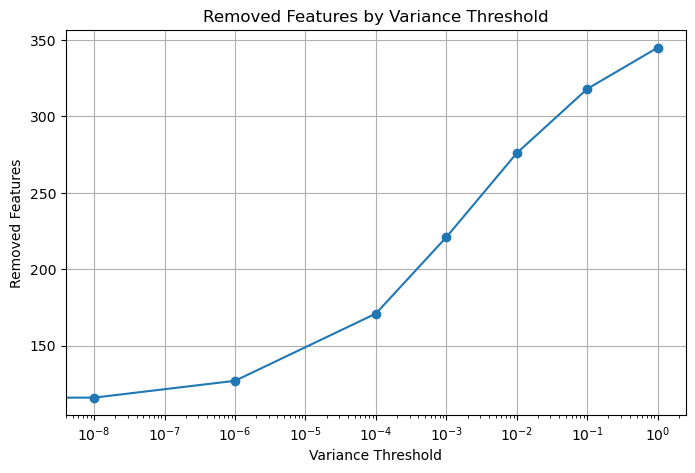

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    variance_threshold_summary["threshold"],
    variance_threshold_summary["removed_features"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Variance Threshold")
plt.ylabel("Removed Features")
plt.title("Removed Features by Variance Threshold")

plt.grid(True)

plt.show()

### Interpretation

- Threshold가 증가할수록 제거되는 Feature 수도 점진적으로 증가하였다.
- Constant Feature(116개) 외에도 매우 작은 분산을 가지는 Low Variance Feature가 다수 존재함을 확인하였다.
- 특히 Threshold가 0.0001 이상부터 제거되는 Feature 수가 빠르게 증가하는 경향을 보였다.
- 따라서 단일 Threshold를 임의로 선택하기보다, 여러 Threshold를 적용한 모델의 성능을 비교하여 최적의 기준을 결정할 예정이다.

## 8. Correlation Analysis

In [32]:
numeric_features = df.drop(
    columns=[
        "Time",
        "Pass/Fail",
    ]
)

In [33]:
corr_matrix = numeric_features.corr()
corr_matrix

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,1.000000,-0.145071,0.004775,-0.007655,-0.011047,NaN,0.002281,0.031510,-0.052731,0.009052,...,-0.070137,-0.028380,0.000225,0.023469,0.019921,0.023605,0.018472,-0.025909,-0.028196,0.004177
1,-0.145071,1.000000,0.005802,-0.007603,-0.001641,NaN,-0.025702,-0.012084,0.031321,0.024015,...,0.073211,0.083463,0.043690,0.002905,-0.001264,0.002273,-0.009417,0.017290,0.010134,0.044834
2,0.004775,0.005802,1.000000,0.298935,0.095891,NaN,-0.136225,-0.273970,0.023609,0.016291,...,-0.018721,-0.010759,-0.006061,0.015711,0.018237,0.015765,-0.025548,-0.029479,-0.030943,-0.033226
3,-0.007655,-0.007603,0.298935,1.000000,-0.058483,NaN,-0.685835,0.138290,-0.103656,0.068998,...,-0.057051,-0.096619,0.009045,0.025461,0.024754,0.026043,0.034779,-0.039309,-0.033780,-0.081157
4,-0.011047,-0.001641,0.095891,-0.058483,1.000000,NaN,-0.074368,-0.916410,-0.026035,0.054619,...,-0.041290,0.088327,0.045361,-0.001301,-0.001598,-0.001617,-0.044016,-0.031145,-0.026204,0.051428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585,0.023605,0.002273,0.015765,0.026043,-0.001617,NaN,-0.039569,0.010345,0.017930,-0.036132,...,-0.000395,-0.000673,-0.197363,0.999890,0.995342,1.000000,0.002744,-0.002931,-0.002531,-0.003801
586,0.018472,-0.009417,-0.025548,0.034779,-0.044016,NaN,-0.041296,0.058171,0.010436,0.033759,...,0.249926,-0.475397,-0.016726,0.002257,0.001606,0.002744,1.000000,0.167913,0.164238,-0.486559
587,-0.025909,0.017290,-0.029479,-0.039309,-0.031145,NaN,0.034184,-0.021472,0.022853,0.059341,...,0.975470,0.396369,-0.024481,-0.002650,-0.002498,-0.002931,0.167913,1.000000,0.974276,0.390813
588,-0.028196,0.010134,-0.030943,-0.033780,-0.026204,NaN,0.032359,-0.020962,0.026261,0.060803,...,1.000000,0.379167,-0.020712,-0.002261,-0.001957,-0.002531,0.164238,0.974276,1.000000,0.389211


In [34]:
import numpy as np

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1,
    ).astype(bool)
)

upper_triangle

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,NaN,-0.145071,0.004775,-0.007655,-0.011047,NaN,0.002281,0.031510,-0.052731,0.009052,...,-0.070137,-0.028380,0.000225,0.023469,0.019921,0.023605,0.018472,-0.025909,-0.028196,0.004177
1,NaN,NaN,0.005802,-0.007603,-0.001641,NaN,-0.025702,-0.012084,0.031321,0.024015,...,0.073211,0.083463,0.043690,0.002905,-0.001264,0.002273,-0.009417,0.017290,0.010134,0.044834
2,NaN,NaN,NaN,0.298935,0.095891,NaN,-0.136225,-0.273970,0.023609,0.016291,...,-0.018721,-0.010759,-0.006061,0.015711,0.018237,0.015765,-0.025548,-0.029479,-0.030943,-0.033226
3,NaN,NaN,NaN,NaN,-0.058483,NaN,-0.685835,0.138290,-0.103656,0.068998,...,-0.057051,-0.096619,0.009045,0.025461,0.024754,0.026043,0.034779,-0.039309,-0.033780,-0.081157
4,NaN,NaN,NaN,NaN,NaN,NaN,-0.074368,-0.916410,-0.026035,0.054619,...,-0.041290,0.088327,0.045361,-0.001301,-0.001598,-0.001617,-0.044016,-0.031145,-0.026204,0.051428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.002744,-0.002931,-0.002531,-0.003801
586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.167913,0.164238,-0.486559
587,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.974276,0.390813
588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.389211


In [35]:
corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation",
]

corr_pairs

,feature_1,feature_2,correlation
0,0,1,-0.145071
1,0,2,0.004775
2,0,3,-0.007655
3,0,4,-0.011047
4,0,6,0.002281
...,...,...,...
111928,586,588,0.164238
111929,586,589,-0.486559
111930,587,588,0.974276
111931,587,589,0.390813


In [36]:
corr_pairs["abs_correlation"] = (
    corr_pairs["correlation"]
    .abs()
)

corr_pairs

,feature_1,feature_2,correlation,abs_correlation
0,0,1,-0.145071,0.145071
1,0,2,0.004775,0.004775
2,0,3,-0.007655,0.007655
3,0,4,-0.011047,0.011047
4,0,6,0.002281,0.002281
...,...,...,...,...
111928,586,588,0.164238,0.164238
111929,586,589,-0.486559,0.486559
111930,587,588,0.974276,0.974276
111931,587,589,0.390813,0.390813


In [37]:
corr_pairs = (
    corr_pairs
    .sort_values(
        "abs_correlation",
        ascending=False,
    )
)

corr_pairs

,feature_1,feature_2,correlation,abs_correlation
72298,209,478,1.000000e+00,1.000000e+00
71285,206,209,1.000000e+00,1.000000e+00
72207,209,347,1.000000e+00,1.000000e+00
30001,74,209,1.000000e+00,1.000000e+00
94588,342,347,1.000000e+00,1.000000e+00
...,...,...,...,...
14512,33,426,-2.799851e-06,2.799851e-06
90562,311,472,1.328041e-06,1.328041e-06
47514,121,219,-8.572395e-07,8.572395e-07
36858,91,421,-1.984651e-07,1.984651e-07


In [38]:
corr_pairs.head(20)

,feature_1,feature_2,correlation,abs_correlation
72298,209,478,1.0,1.0
71285,206,209,1.0,1.0
72207,209,347,1.0,1.0
30001,74,209,1.0,1.0
94588,342,347,1.0,1.0
72202,209,342,1.0,1.0
30186,74,478,1.0,1.0
30090,74,342,1.0,1.0
30095,74,347,1.0,1.0
97535,358,544,1.0,1.0


In [40]:
corr_pairs["abs_correlation"].describe()

count    1.119330e+05
mean     4.540295e-02
std      9.660804e-02
min      3.098216e-08
25%      1.029546e-02
50%      2.342514e-02
75%      4.493278e-02
max      1.000000e+00
Name: abs_correlation, dtype: float64

In [52]:
corr_pairs["abs_correlation"].quantile(
    [
        0.5,
        0.75,
        0.9,
        0.91,
        0.92,
        0.93,
        0.94,
        0.95,
        0.96,
        0.97,
        0.98,
        0.99,
    ]
)

0.50    0.023425
0.75    0.044933
0.90    0.081129
0.91    0.086847
0.92    0.093813
0.93    0.102817
0.94    0.114001
0.95    0.129013
0.96    0.151257
0.97    0.189877
0.98    0.291789
0.99    0.593868
Name: abs_correlation, dtype: float64

In [51]:
corr_pairs[corr_pairs['abs_correlation'] > 0.1]

,feature_1,feature_2,correlation,abs_correlation
72298,209,478,1.000000,1.000000
71285,206,209,1.000000,1.000000
72207,209,347,1.000000,1.000000
30001,74,209,1.000000,1.000000
94588,342,347,1.000000,1.000000
...,...,...,...,...
24420,59,444,-0.100041,0.100041
94019,338,589,0.100041,0.100041
8669,20,405,0.100028,0.100028
14344,33,196,0.100005,0.100005


In [58]:
corr_pairs[corr_pairs['abs_correlation'] > 0.9]

,feature_1,feature_2,correlation,abs_correlation
72298,209,478,1.000000,1.000000
71285,206,209,1.000000,1.000000
72207,209,347,1.000000,1.000000
30001,74,209,1.000000,1.000000
94588,342,347,1.000000,1.000000
...,...,...,...,...
86623,293,388,0.901152,0.901152
61517,164,436,0.900980,0.900980
68487,196,343,0.900949,0.900949
61098,163,300,0.900730,0.900730


In [53]:
for threshold in [0.9, 0.95, 0.99]:
    print(
        threshold,
        (corr_pairs["abs_correlation"] >= threshold).sum()
    )

0.9 419
0.95 329
0.99 158


In [57]:
high_corr = corr_pairs[corr_pairs["abs_correlation"] >= 0.95]

pd.concat([
        high_corr["feature_1"],
        high_corr["feature_2"]
        ]).value_counts()

421    9
516    9
382    9
518    9
244    9
      ..
239    1
94     1
212    1
163    1
407    1
Name: count, Length: 309, dtype: int64

### Observation

- 상관계수가 가장 높은 Feature Pair를 확인하였다.
- 일부 Feature는 매우 높은 상관관계를 가지며 동일한 정보를 포함할 가능성이 있다.
- 이러한 Feature는 Feature Selection 단계에서 제거 후보로 사용할 예정이다.